In [1]:
import pandas as pd
import numpy as np
import xarray as xr
import os
import matplotlib.pyplot as plt

import sys
sys.path.append('..//')
from utils_mitgcm import open_mitgcm_ds_from_config
from utils_energy_analysis import *
from utils_plot import plot_colors

In [17]:
lake = 'zug'

In [18]:
base_folder = rf"/storage/alplakes_test/{lake}_100m_2025"

In [19]:
output_folder = os.path.join(base_folder, 'wind_analysis')
os.makedirs(output_folder, exist_ok=True)

In [20]:
bin_folder = os.path.join(rf'/home/leroquan@eawag.wroot.emp-eaw.ch/work_space/{lake}_100m_2025', 'binary_data')

# Import wind

In [21]:
ds_wind = xr.open_dataset(os.path.join(bin_folder, "wind.nc"))

In [7]:
def get_wind_direction(direction):
    if direction < 45 or direction >= 315:
        return 'N'
    elif direction >= 45 and direction < 135:
        return 'E'
    elif direction >= 135 and direction < 225:  
        return 'S'
    elif direction >= 225 and direction < 315:
        return 'W'

In [42]:
direction_str = xr.apply_ufunc(get_wind_direction, ds_wind['direction'].sel(time=slice(pd.to_datetime("2025-09-01"), pd.to_datetime("2025-10-01"))), vectorize=True, dask='parallelized', output_dtypes=[str])

/home/leroquan@eawag.wroot.emp-eaw.ch/miniconda3/envs/horizontal_structures/lib/python3.11/site-packages/numpy/lib/_function_base_impl.py:2605: RuntimeWarning: invalid value encountered in get_wind_direction (vectorized)
  outputs = ufunc(*inputs)


In [44]:
main_direction = []
for tt in range(len(direction_str)):
    count_N = np.count_nonzero(direction_str.isel(time=tt).values == 'N')
    count_E = np.count_nonzero(direction_str.isel(time=tt).values == 'E')
    count_S = np.count_nonzero(direction_str.isel(time=tt).values == 'S')
    count_W = np.count_nonzero(direction_str.isel(time=tt).values == 'W')
    if count_N > count_E and count_N > count_S and count_N > count_W:
        main_direction.append(0)
    elif count_E > count_S and count_E > count_W:
        main_direction.append(1)
    elif count_S > count_W:
        main_direction.append(2)
    else:
        main_direction.append(3)

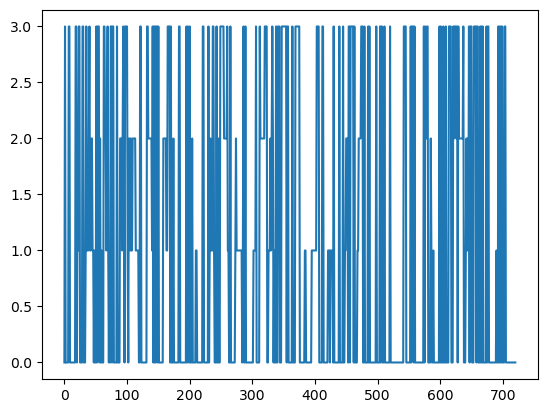

In [45]:
plt.plot(main_direction)

# Import Eddy volume

In [8]:
df_eddy_volume = pd.read_csv(
    os.path.join(base_folder, 
                 'outputs_swirl', 
                 'eddy_statistics',
                 'volume_timeserie_upper_layer.csv'), index_col=0)

FileNotFoundError: [Errno 2] No such file or directory: '/storage/alplakes_test/lucerne_100m_2025/outputs_swirl/eddy_statistics/volume_timeserie_upper_layer.csv'

<Axes: xlabel='date'>

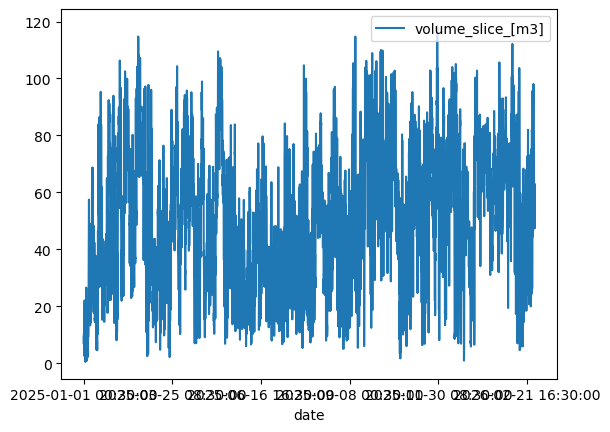

In [ ]:
df_eddy_volume.plot()

# Point analysis

In [22]:
xx = 0
yy = 0
if lake=='zug':
    xx = 20
    yy = 100
if lake=='lucerne':
    xx=90
    yy=100

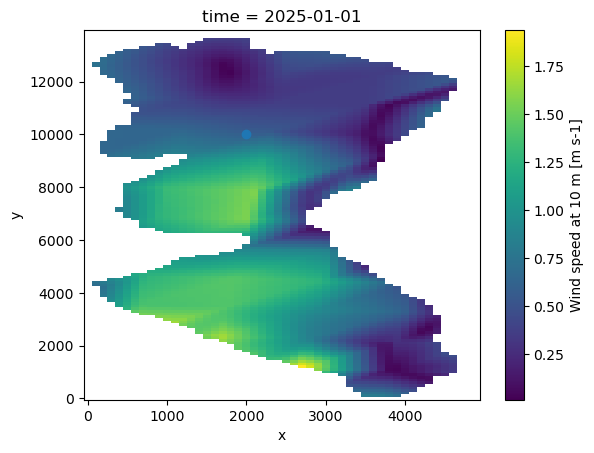

In [23]:
ds_wind.speed.isel(time=0).plot()
plt.scatter(xx*100, yy*100)

In [25]:
ds_lucerne=xr.open_dataset(os.path.join(rf'/home/leroquan@eawag.wroot.emp-eaw.ch/work_space/lucerne_100m_2025', 'binary_data', "wind.nc"))

In [31]:
import matplotlib.dates as mdates

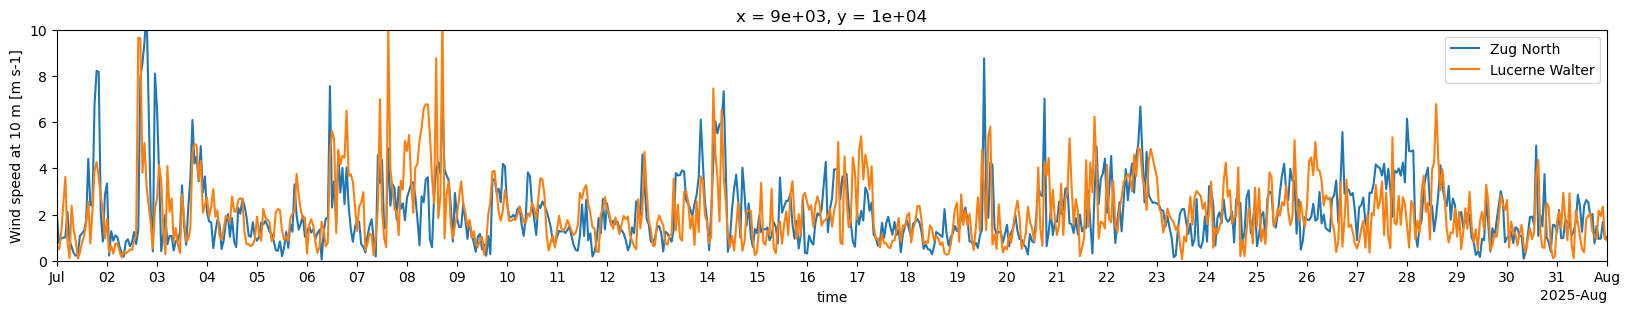

In [32]:
plt.figure(figsize=(20,3))
ds_wind.speed.isel(x=xx,y=yy).plot(label='Zug North')
ds_lucerne.speed.isel(x=90,y=100).plot(label='Lucerne Walter')
plt.xlim(pd.to_datetime("2025-07-01"), pd.to_datetime("2025-08-01"))
plt.ylim(0,10)
plt.gca().xaxis.set_major_locator(mdates.DayLocator())
plt.legend()

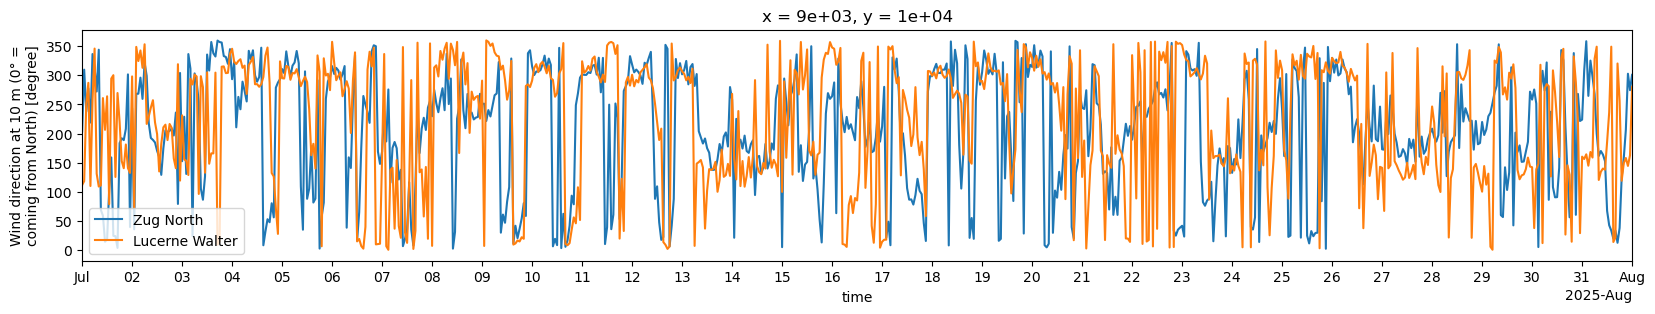

In [33]:
plt.figure(figsize=(20,3))
ds_wind.direction.isel(x=xx,y=yy).plot(label='Zug North')
ds_lucerne.direction.isel(x=90,y=100).plot(label='Lucerne Walter')
plt.xlim(pd.to_datetime("2025-07-01"), pd.to_datetime("2025-08-01"))
plt.gca().xaxis.set_major_locator(mdates.DayLocator())
plt.legend()

In [27]:
direction_str = xr.apply_ufunc(get_wind_direction, ds_wind['direction'].isel(x=xx,y=yy).sel(time=slice(pd.to_datetime("2025-09-01"), pd.to_datetime("2025-10-01"))), vectorize=True, dask='parallelized', output_dtypes=[str])

(np.float64(20332.0), np.float64(20362.0))

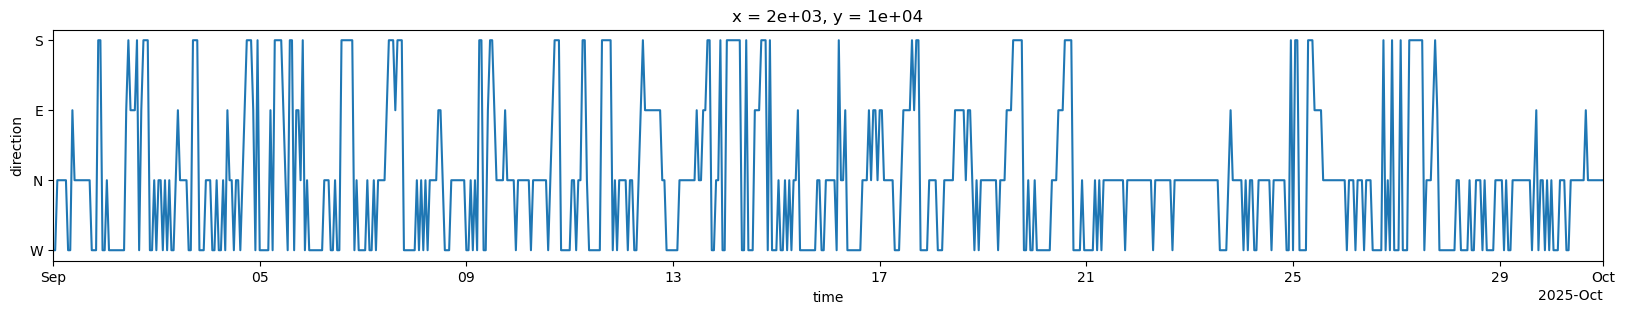

In [28]:
plt.figure(figsize=(20,3))
direction_str.plot()
plt.xlim(pd.to_datetime("2025-09-01"), pd.to_datetime("2025-10-01"))

# Eddy volume per wind direction

In [11]:
from bokeh.plotting import figure, show
from bokeh.io import output_notebook

output_notebook()

Loading BokehJS ...

In [29]:
from bokeh.models import Range1d, LinearAxis

# --- Create the base figure (left axis) ---
p = figure(
    title='Eddy surface per wind direction',
    x_axis_type='datetime',
    width=2000,
    height=450,
    x_axis_label='Date',
    y_axis_label='Eddy volume (m³)',
    tools='xpan,xwheel_zoom,box_zoom,reset,save',
    active_scroll='xwheel_zoom',
)

# Left axis: Eddy volume
p.line(
    x=pd.to_datetime(df_eddy_volume.index),
    y=df_eddy_volume,
    legend_label='Eddy volume',
    line_color=plot_colors.eddy_color
)

# Right axis: Wind direction
p.extra_y_ranges = {
    "wind": Range1d(start=0, end=7)
}

p.add_layout(
    LinearAxis(y_range_name="wind", axis_label="Wind direction (°)"),
    'right'
)

p.line(
    x=ds_wind.time,
    y=ds_wind.speed.isel(x=xx,y=yy),
    y_range_name="wind",
    legend_label='Wind direction',
    line_color=plot_colors.wind_color
)

p.legend.location = 'top_right'
p.legend.click_policy = 'hide'

show(p)